<a href="https://colab.research.google.com/github/AshakUmesh/Learn-Python/blob/main/Ciphers/IS_Ciphers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert string to ASCII bytes
def str_to_bytes(s):
    return s.encode('ascii')

# Simple XOR encryption with fixed key
key = b'secretkey1234567'

def simple_xor_encrypt(plaintext_bytes):
    return bytes([b ^ key[i % len(key)] for i, b in enumerate(plaintext_bytes)])

# Hamming distance (bit-level)
def hamming_distance_bits(b1, b2):
    xor_result = bytes([x ^ y for x, y in zip(b1, b2)])
    return sum(bin(byte).count('1') for byte in xor_result)

# Diffusion score
def diffusion_score(b1, b2):
    return hamming_distance_bits(b1, b2) / (len(b1) * 8)

# Original plaintext
original_plaintext = "HELLO WORLD"
original_bytes = str_to_bytes(original_plaintext)
original_cipher = simple_xor_encrypt(original_bytes)

# Results storage
results = []
bits_total = len(original_cipher) * 8

# For each character position
for i, ch in enumerate(original_plaintext):
    for replacement in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
        # If original is a letter, skip identical replacement
        if ch.isalpha() and replacement == ch:
            continue

        modified = original_plaintext[:i] + replacement + original_plaintext[i+1:]
        var_bytes = str_to_bytes(modified)
        var_cipher = simple_xor_encrypt(var_bytes)

        bit_diff = hamming_distance_bits(original_cipher, var_cipher)
        bit_same = bits_total - bit_diff
        score = diffusion_score(original_cipher, var_cipher)

        results.append({
            'Position Changed': i + 1,
            'Original Char': ch,
            'Replaced With': replacement,
            'Modified Plaintext': modified,
            'Bit Differences': bit_diff,
            'Bit Same': bit_same,
            'Diffusion Score': score
        })

# Convert to DataFrame
df = pd.DataFrame(results)

# ✅ Show all rows in output
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print(df)

# ✅ Also show row count and distribution per position
print("\nTotal rows generated:", df.shape[0])   # should be 276
print("\nCount per position:")
print(df.groupby("Position Changed").size())


     Position Changed Original Char Replaced With Modified Plaintext  Bit Differences  Bit Same  Diffusion Score
0                   1             H             A        AELLO WORLD                2        86         0.022727
1                   1             H             B        BELLO WORLD                2        86         0.022727
2                   1             H             C        CELLO WORLD                3        85         0.034091
3                   1             H             D        DELLO WORLD                2        86         0.022727
4                   1             H             E        EELLO WORLD                3        85         0.034091
5                   1             H             F        FELLO WORLD                3        85         0.034091
6                   1             H             G        GELLO WORLD                4        84         0.045455
7                   1             H             I        IELLO WORLD                1        87 

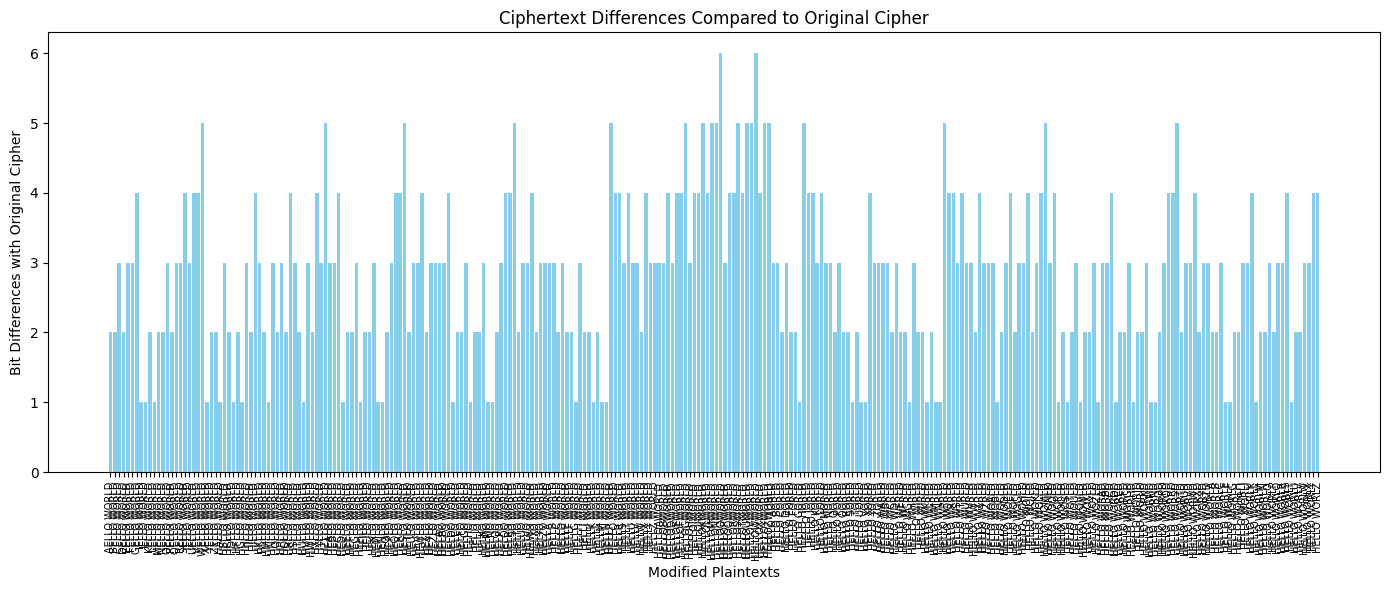

In [27]:
plt.figure(figsize=(14, 6))
plt.bar(range(len(df)), df["Bit Differences"], color="skyblue")
plt.xticks(range(len(df)), df["Modified Plaintext"], rotation=90, fontsize=7)
plt.ylabel("Bit Differences with Original Cipher")
plt.xlabel("Modified Plaintexts")
plt.title("Ciphertext Differences Compared to Original Cipher")
plt.tight_layout()
plt.show()

KHOOR ZRUOG
